In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F          
from torch.utils.data import DataLoader  
from torchvision import datasets, transforms

In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix  
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
transform = transforms.ToTensor()


In [40]:
train_data = datasets.MNIST(root='../Data',train=True, download=True,transform=transform)
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: ../Data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [41]:
test_data = datasets.MNIST(
    root='../Data',
    train=False,
    download=True,
    transform=transform
)

In [43]:
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
test_loader = DataLoader(test_data, batch_size=500, shuffle=False)

In [44]:
type(train_data)

torchvision.datasets.mnist.MNIST

In [45]:
train_data[0]

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 

In [46]:
type(train_data[0])

tuple

In [84]:
image,label = train_data[0]


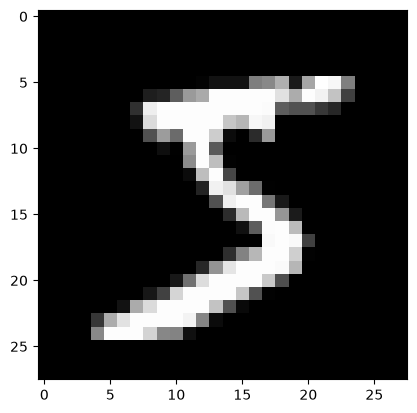

In [85]:
plt.imshow(image.reshape((28,28)),cmap='gray')
plt.show()

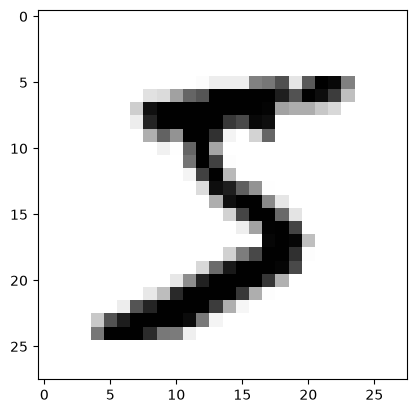

In [86]:
plt.imshow(image.reshape((28,28)),cmap='gist_yarg')  
plt.show()

In [87]:
torch.manual_seed(101)  
train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
test_loader = DataLoader(test_data, batch_size=500, shuffle=False)

In [88]:
print(test_data)

Dataset MNIST
    Number of datapoints: 10000
    Root location: ../Data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [89]:

from torchvision.utils import make_grid
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}')) 

In [90]:
for images,labels in train_loader: 
    break

In [91]:
print('Labels: ', labels[:12].numpy())


Labels:  [   7    2    3    5    8    5    3    6    9    9    1    3]


In [92]:
im = make_grid(images[:12], nrow=12)

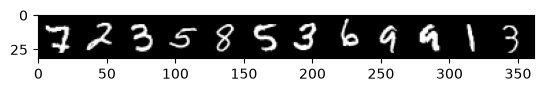

In [93]:

plt.imshow(np.transpose(im.numpy(),(1,2,0)));
plt.show()

In [94]:
class MultilayerPerceptron(nn.Module):
    def __init__(self, in_sz=784, out_sz=10, layers=[120,84]):
        super().__init__()
        self.fc1 = nn.Linear(in_sz,layers[0])
        self.fc2 = nn.Linear(layers[0],layers[1])
        self.fc3 = nn.Linear(layers[1],out_sz)
    
    def forward(self,X):
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

In [ ]:

torch.manual_seed(101)
model = MultilayerPerceptron()
model

In [ ]:
for param in model.parameters():
    print(param.numel())

In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)


In [ ]:
images.view(100,-1)


In [ ]:

images.view(100,-1).shape

In [ ]:
import time 
start_time = time.time()
epochs = 10 
train_losses = []
test_losses = []
train_correct = []
test_correct = []


In [ ]:
for i in range(epochs):

    trn_corr = 0
    tst_corr = 0

    for b,(X_train,y_train) in enumerate(train_loader):

        b+=1

        y_pred = model(X_train.view(100,-1))
        loss = criterion(y_pred,y_train)
        predicted = torch.max(y_pred.data,1)[1]   
        batch_corr = (predicted == y_train).sum()
        trn_corr += batch_corr

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if b%200 == 0:

            acc = trn_corr.item()*100/(100*b)
            print(f'Epoch{i}  batch {b}   loss: {loss.item()}  accuracy:{acc}')
            train_losses.append(loss)
    train_correct.append(trn_corr)

    with torch.no_grad():
        for b, (X_test,y_test) in enumerate(test_loader):
            y_val = model(X_test.view(500,-1))
            predicted = torch.max(y_val.data,1)[1]
            tst_corr += (predicted ==y_test).sum()

    loss = criterion(y_val,y_test)
    test_losses.append(loss)
    test_correct.append(tst_corr)
    total_time = time.time() - start_time
print(f'Durations: {total_time/60} mins')



In [ ]:
train_losses_np = [loss.detach().numpy() for loss in train_losses]

plt.plot(train_losses_np, label='Training loss')
plt.legend()
plt.show()

In [ ]:
train_losses_np = [loss.detach().numpy() for loss in train_losses]
test_losses_np = [loss.detach().numpy() for loss in test_losses]
plt.plot(train_losses_np, label='Training loss')
plt.plot(test_losses_np, label='Validation Loss')
plt.legend()
plt.show()

In [ ]:
train_correct[0]/600


In [ ]:
train_acc = [t/600 for t in train_correct]


In [76]:
train_acc


[tensor(89.4750),
 tensor(95.3233),
 tensor(96.7417),
 tensor(97.5350),
 tensor(98.0150),
 tensor(98.4433),
 tensor(98.6867),
 tensor(99.0083),
 tensor(99.0933),
 tensor(99.3067)]

In [77]:
test_acc = [t/100 for t in test_correct]


In [79]:
test_load_all = DataLoader(test_data, batch_size=10000, shuffle=False)


In [80]:
with torch.no_grad():
    correct = 0
    
    for X_test, y_test in test_load_all:
        y_val = model(X_test.view(len(X_test), -1)) 
        predicted = torch.max(y_val,1)[1]
        correct += (predicted == y_test).sum()

In [81]:
100*correct.item()/len(test_data)


97.77

In [82]:
confusion_matrix(predicted.view(-1), y_test.view(-1))


array([[ 970,    0,    4,    0,    0,    2,    4,    1,    6,    3],
       [   0, 1128,    2,    0,    1,    0,    2,    9,    1,    3],
       [   0,    2, 1012,    4,    4,    0,    0,    8,    4,    0],
       [   2,    1,    2,  983,    0,    5,    1,    3,   15,    4],
       [   1,    0,    2,    0,  960,    1,    3,    2,    5,    4],
       [   1,    0,    0,   15,    1,  876,    4,    0,    9,    5],
       [   3,    1,    3,    0,    6,    5,  944,    0,    4,    1],
       [   0,    0,    3,    1,    1,    0,    0,  997,    3,    3],
       [   1,    3,    3,    0,    0,    2,    0,    2,  922,    1],
       [   2,    0,    1,    7,    9,    1,    0,    6,    5,  985]])